In [1]:
# 数据处理基础库
import pandas as pd
import numpy as np

# 分割训练/测试集（文档要求）
from sklearn.model_selection import train_test_split

# 回归模型+评估指标
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

# 分类模型+评估指标
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

# 可视化混淆矩阵（俄语显示专用设置）
import matplotlib.pyplot as plt
import seaborn as sns
# Windows系统默认字体，完美支持俄语
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

In [8]:
# 读取预处理好的数据
df = pd.read_csv("processed_titanic.csv")

# 删除：无用列 + 非数值的Cabin列（解决你之前的报错！）
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# 查看数据
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,0.271174,1,0,0.014151,True,False,True
1,1,1,0.472229,1,0,0.139136,False,False,False
2,1,3,0.321438,0,0,0.015469,False,False,True
3,1,1,0.434531,1,0,0.103644,False,False,True
4,0,3,0.434531,0,0,0.015713,True,False,True


In [9]:
# 特征X（所有用于预测的列）
X = df.drop(['Survived', 'Fare'], axis=1)

# 回归目标：预测船票价格 Fare
y_reg = df['Fare']
# 分类目标：预测是否存活 Survived
y_cla = df['Survived']

# 分割数据 8:2
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_cla, X_test_cla, y_train_cla, y_test_cla = train_test_split(X, y_cla, test_size=0.2, random_state=42)

print("Размер обучающего набора：", X_train_reg.shape)
print("размер тестового набора：", X_test_reg.shape)

训练集大小： (712, 7)
测试集大小： (179, 7)


In [10]:
# 训练线性回归模型
model = LinearRegression()
model.fit(X_train_reg, y_train_reg)

# 预测
y_pred_reg = model.predict(X_test_reg)

# 查看结果
print("Фактическая цена,：", y_test_reg.values[:10])
print("прогнозируемая цена：", np.round(y_pred_reg[:10], 2))

真实价格： [0.02975782 0.02049464 0.01546857 0.06441171 0.02194234 0.15390495
 0.01512699 0.03513366 0.01512699 0.05130158]
预测价格： [ 0.07  0.06 -0.    0.09  0.06  0.13  0.02  0.02  0.02  0.18]


In [11]:
# 基础模型评估
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = root_mean_squared_error(y_test_reg, y_pred_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)

print("=== Оценка линейной регрессии ===")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# 优化模型（Ridge正则化）
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_reg, y_train_reg)
y_pred_ridge = ridge.predict(X_test_reg)

print("\n=== Оценка результатов после оптимизации评估 ===")
print(f"RMSE: {root_mean_squared_error(y_test_reg, y_pred_ridge):.2f}")

=== 线性回归评估 ===
MSE: 0.00
RMSE: 0.06
MAE: 0.04

=== 优化后评估 ===
RMSE: 0.06


In [14]:
# 训练分类模型
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_cla, y_train_cla)

# 预测
y_pred_cla = clf.predict(X_test_cla)
#真实存活
#预测存活
print("Настоящее выживание：", y_test_cla.values[:10])
print("Прогнозируемая выживаемость：", y_pred_cla[:10])

Настоящее выживание： [1 0 0 1 1 1 1 0 1 1]
Прогнозируемая выживаемость： [0 0 0 1 1 1 1 0 1 1]


Точность классификации: 0.80


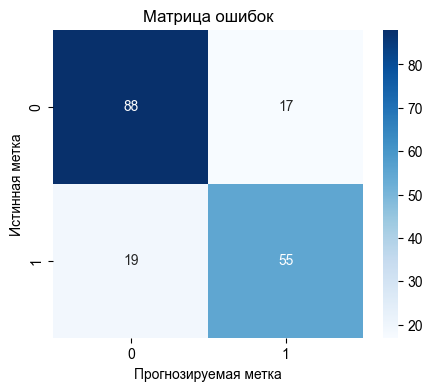


Отчет классификации:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [18]:
# 准确率
acc = accuracy_score(y_test_cla, y_pred_cla)
print(f"Точность классификации: {acc:.2f}")

# 俄语混淆矩阵
cm = confusion_matrix(y_test_cla, y_pred_cla)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

# 俄语标签
plt.title("Матрица ошибок")
plt.ylabel("Истинная метка")
plt.xlabel("Прогнозируемая метка")
plt.show()

# 分类报告
print("\nОтчет классификации:")
print(classification_report(y_test_cla, y_pred_cla))


In [19]:
import pandas as pd
import numpy as np

# 保存回归结果
reg_res = pd.DataFrame({"Реальная цена": y_test_reg.values, "Предсказанная цена": np.round(y_pred_reg, 2)})
reg_res.to_csv("reg_result.csv", index=False)

# 保存分类结果
cla_res = pd.DataFrame({"Реальное выживание": y_test_cla.values, "Предсказанное выживание": y_pred_cla})
cla_res.to_csv("cla_result.csv", index=False)

print(Все результаты успешно сохранены!")

✅ Все результаты успешно сохранены!
